# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Semua library berhasil diimport!')
print(f'Pandas version : {pd.__version__}')
print(f'NumPy version  : {np.__version__}')

Semua library berhasil diimport!
Pandas version : 2.2.2
NumPy version  : 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [13]:
RAW_PATH = '/content/heart_raw.csv'

df = pd.read_csv(RAW_PATH)
print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'Nama kolom    : {df.columns.tolist()}')

Dataset berhasil dimuat!
Jumlah baris  : 1025
Jumlah kolom  : 14
Nama kolom    : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [15]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.000,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.800,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.000,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.000,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.400,1,1,3,0


In [16]:
df.sample(5, random_state=42)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
527,62,0,0,124,209,0,1,163,0,0.000,2,0,2,1
359,53,0,2,128,216,0,0,115,0,0.000,2,0,0,1
447,55,1,0,160,289,0,0,145,1,0.800,1,1,3,0
31,50,0,1,120,244,0,1,162,0,1.100,2,0,2,1
621,48,1,0,130,256,1,0,150,1,0.000,2,2,3,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [18]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,0.696,0.942,131.612,246.000,0.149,0.530,149.114,0.337,1.072,1.385,0.754,2.324,0.513
std,9.072,0.460,1.030,17.517,51.593,0.357,0.528,23.006,0.473,1.175,0.618,1.031,0.621,0.500
min,29.000,0.000,0.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,48.000,0.000,0.000,120.000,211.000,0.000,0.000,132.000,0.000,0.000,1.000,0.000,2.000,0.000
50%,56.000,1.000,1.000,130.000,240.000,0.000,1.000,152.000,0.000,0.800,1.000,0.000,2.000,1.000
75%,61.000,1.000,2.000,140.000,275.000,0.000,1.000,166.000,1.000,1.800,2.000,1.000,3.000,1.000
max,77.000,1.000,3.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,2.000,4.000,3.000,1.000


In [19]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
sex,1025.000,0.696,0.460,0.000,0.000,1.000,1.000,1.000
cp,1025.000,0.942,1.030,0.000,0.000,1.000,2.000,3.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
fbs,1025.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,1025.000,0.530,0.528,0.000,0.000,1.000,1.000,2.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
exang,1025.000,0.337,0.473,0.000,0.000,0.000,1.000,1.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200


In [20]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('Tidak ada missing values pada dataset ini.')
else:
    print('Kolom dengan missing values:')
    display(missing_df)

Tidak ada missing values pada dataset ini.


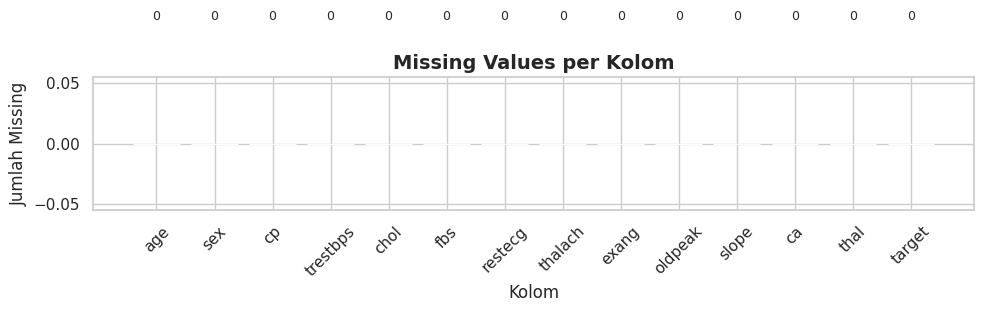

Total missing values: 0


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_counts = df.isnull().sum()
colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in missing_counts]
bars = ax.bar(missing_counts.index, missing_counts.values, color=colors, edgecolor='white')
ax.set_title('Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Kolom')
ax.set_ylabel('Jumlah Missing')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, missing_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Total missing values: {df.isnull().sum().sum()}')

In [22]:
dup_count = df.duplicated().sum()
print(f'Jumlah baris duplikat: {dup_count}')

if dup_count > 0:
    print('Contoh baris duplikat:')
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

Jumlah baris duplikat: 723
Contoh baris duplikat:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
60,29,1,1,130,204,0,0,202,0,0.000,2,0,2,1
64,29,1,1,130,204,0,0,202,0,0.000,2,0,2,1
118,29,1,1,130,204,0,0,202,0,0.000,2,0,2,1
668,29,1,1,130,204,0,0,202,0,0.000,2,0,2,1
12,34,0,1,118,210,0,1,192,0,0.700,2,0,2,1
15,34,0,1,118,210,0,1,192,0,0.700,2,0,2,1
779,34,0,1,118,210,0,1,192,0,0.700,2,0,2,1
143,34,1,3,118,182,0,0,174,0,0.000,2,0,2,1
201,34,1,3,118,182,0,0,174,0,0.000,2,0,2,1
572,34,1,3,118,182,0,0,174,0,0.000,2,0,2,1


Distribusi Target Variable:
  0 (No Disease): 499 (48.7%)
  1 (Disease)   : 526 (51.3%)


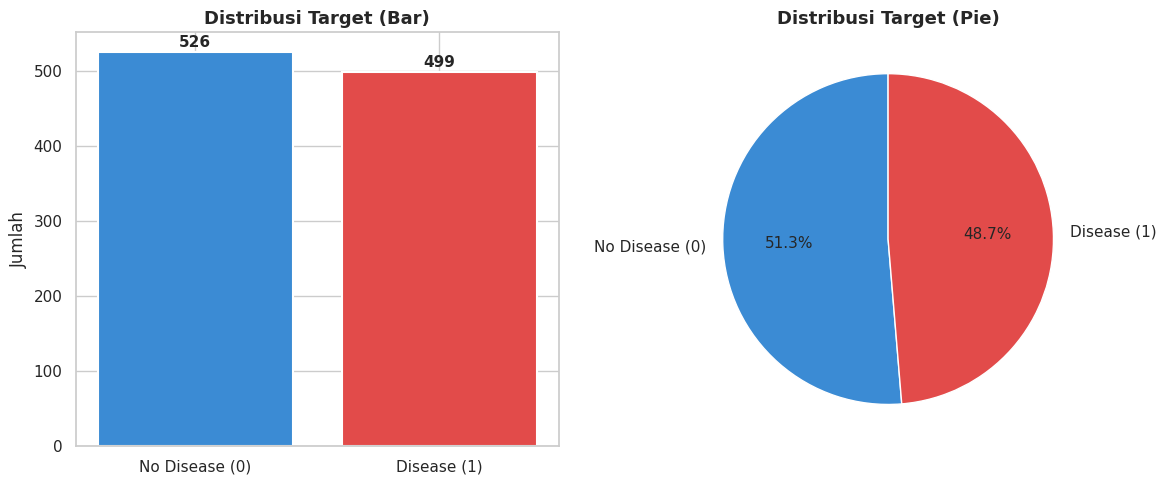

In [23]:
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

print('Distribusi Target Variable:')
print(f'  0 (No Disease): {target_counts[0]} ({target_pct[0]:.1f}%)')
print(f'  1 (Disease)   : {target_counts[1]} ({target_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_target = ['#3B8BD4', '#E24B4A']
bars = axes[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values,
                    color=colors_target, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Target (Bar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Disease (0)', 'Disease (1)'],
            colors=colors_target, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Distribusi Target (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Kolom numerik: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


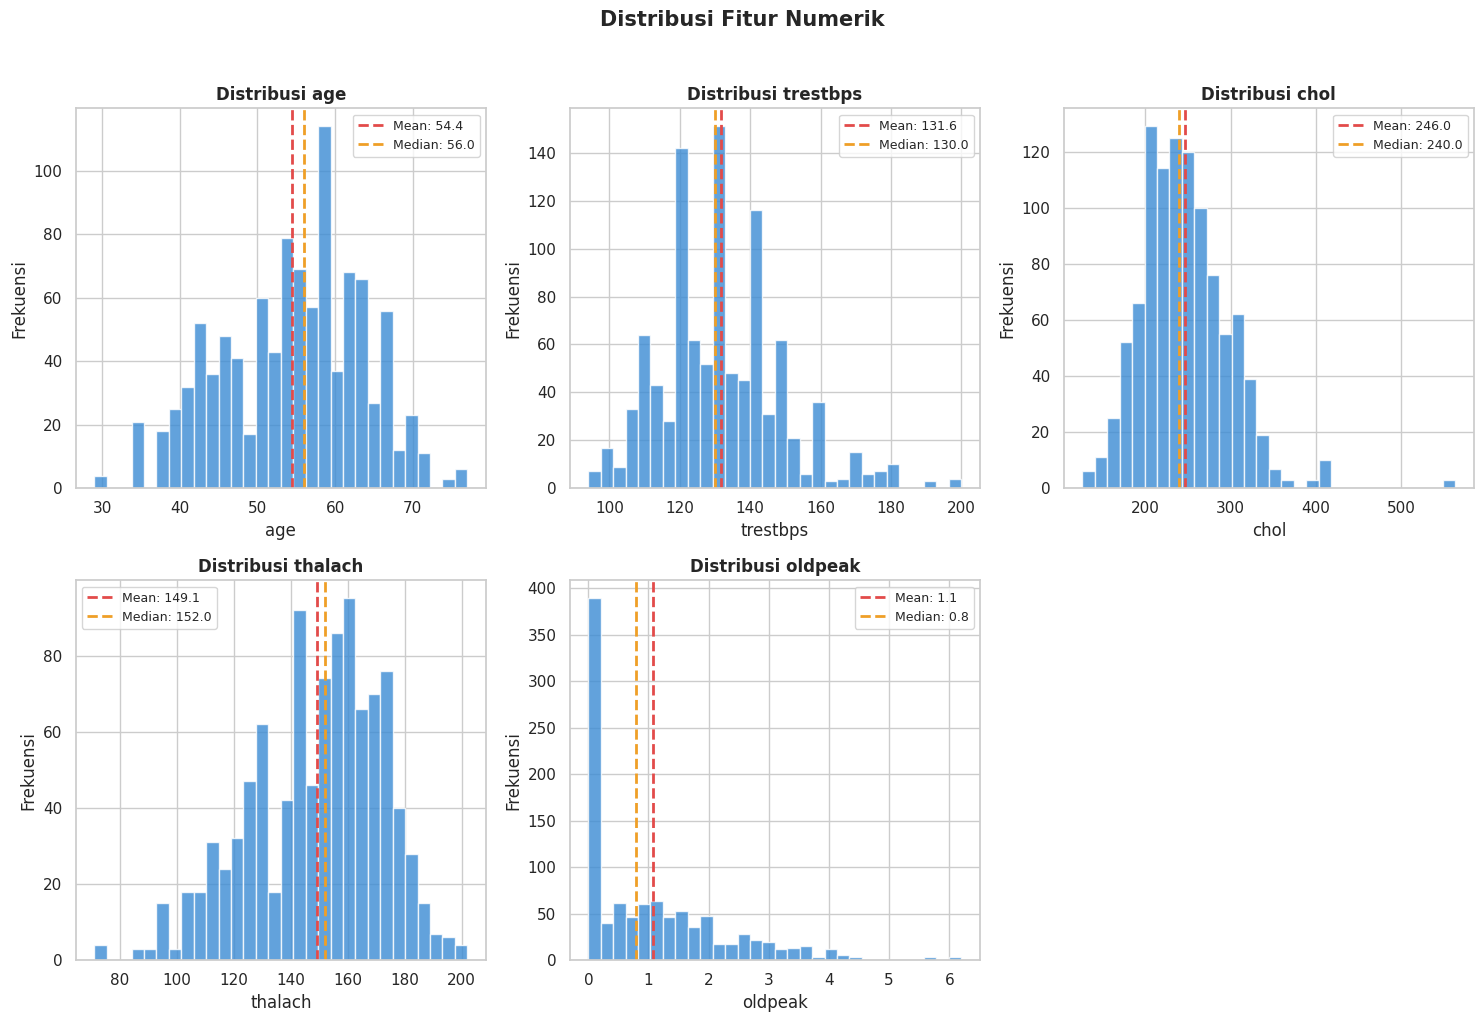

In [24]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(f'Kolom numerik: {numeric_cols}')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='#3B8BD4', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='#E24B4A', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='#EF9F27', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

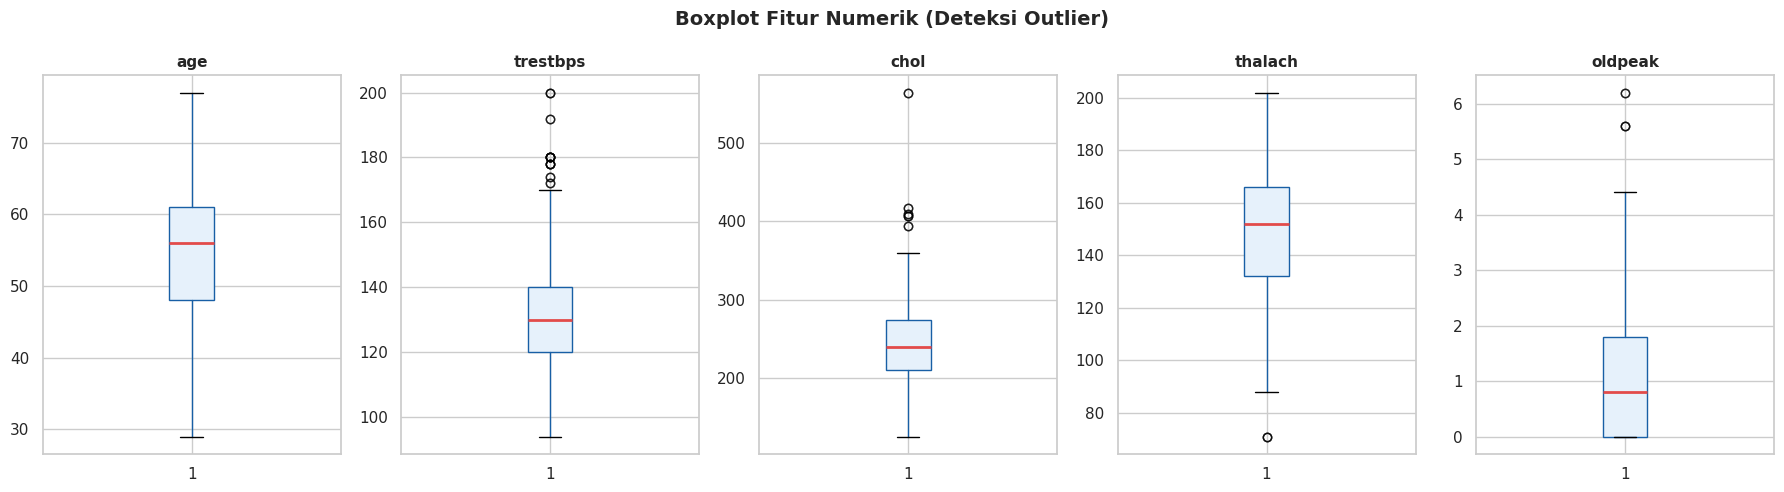

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#E6F1FB', color='#185FA5'),
                    medianprops=dict(color='#E24B4A', linewidth=2),
                    whiskerprops=dict(color='#185FA5'),
                    flierprops=dict(marker='o', color='#E24B4A', alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

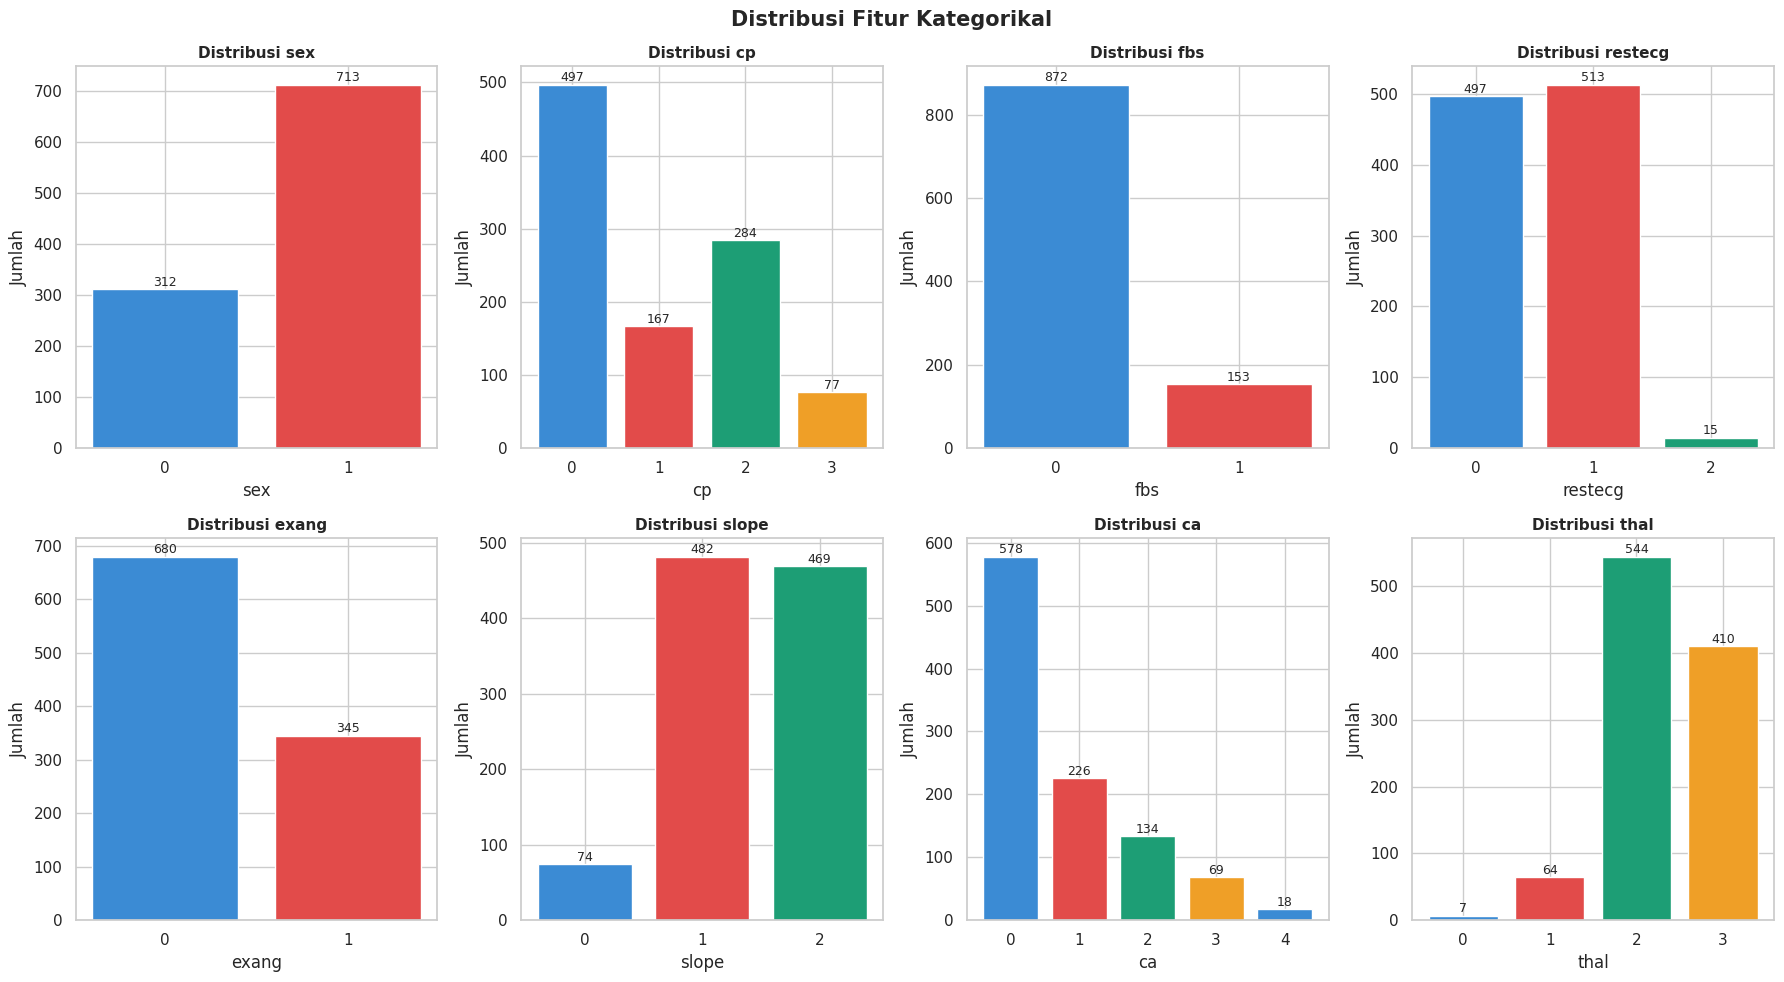

In [26]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
palette = ['#3B8BD4', '#E24B4A', '#1D9E75', '#EF9F27']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                        color=palette[:len(counts)], edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

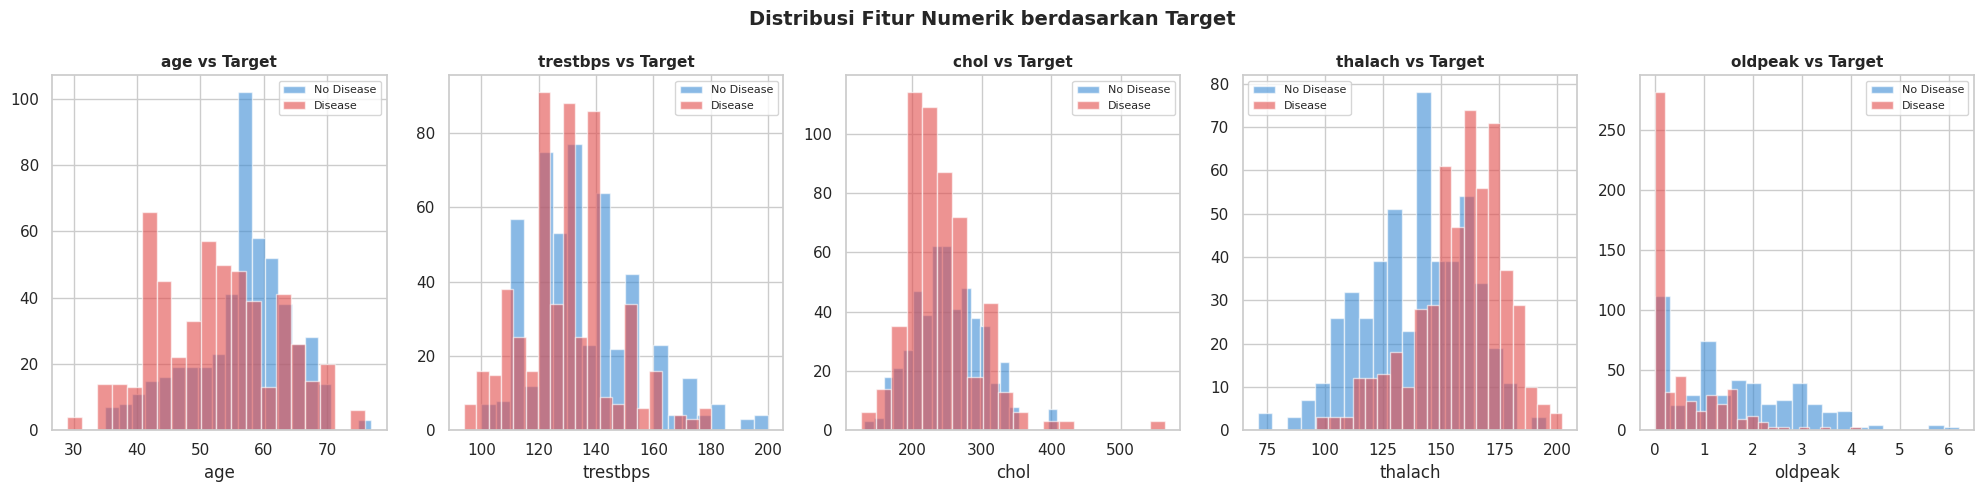

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(numeric_cols):
    for target_val, color, label in zip([0, 1], ['#3B8BD4', '#E24B4A'], ['No Disease', 'Disease']):
        data = df[df['target'] == target_val][col]
        axes[i].hist(data, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

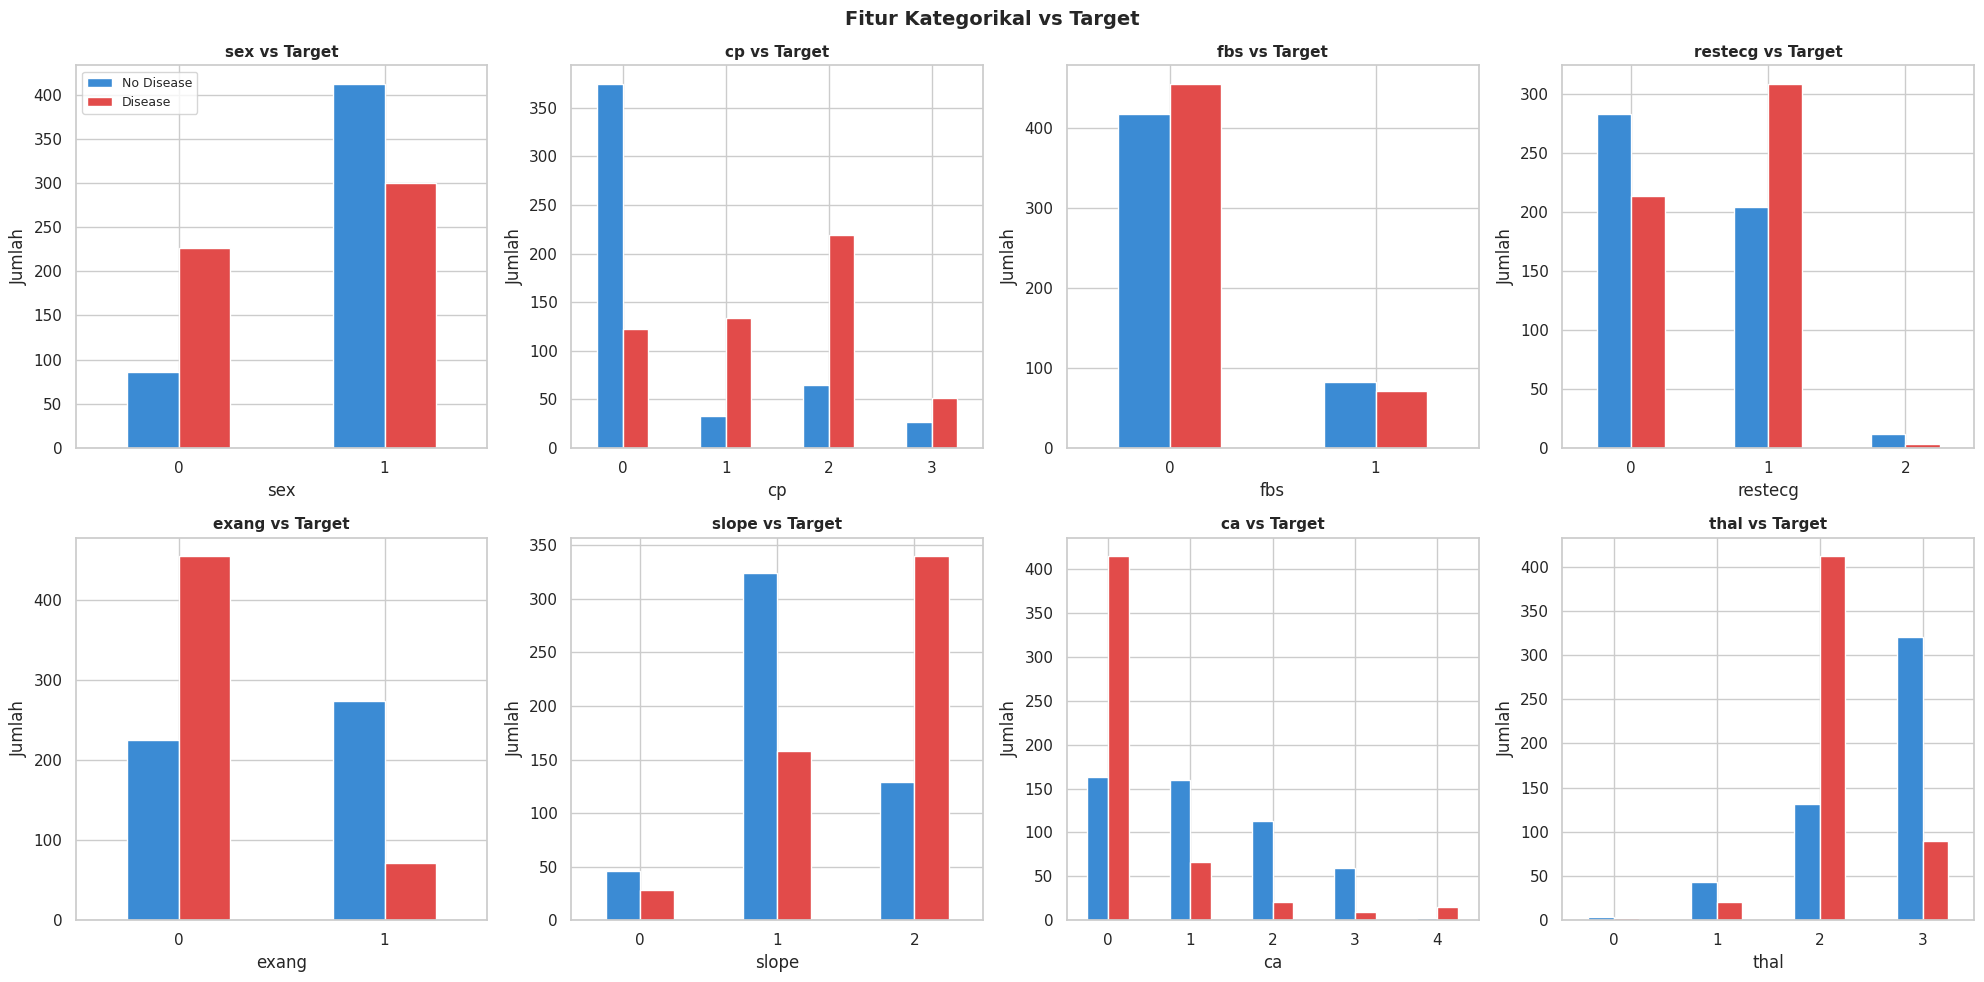

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#3B8BD4', '#E24B4A'],
            edgecolor='white', rot=0, legend=(i == 0))
    axes[i].set_title(f'{col} vs Target', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    if i == 0:
        axes[i].legend(['No Disease', 'Disease'], fontsize=9)

plt.suptitle('Fitur Kategorikal vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

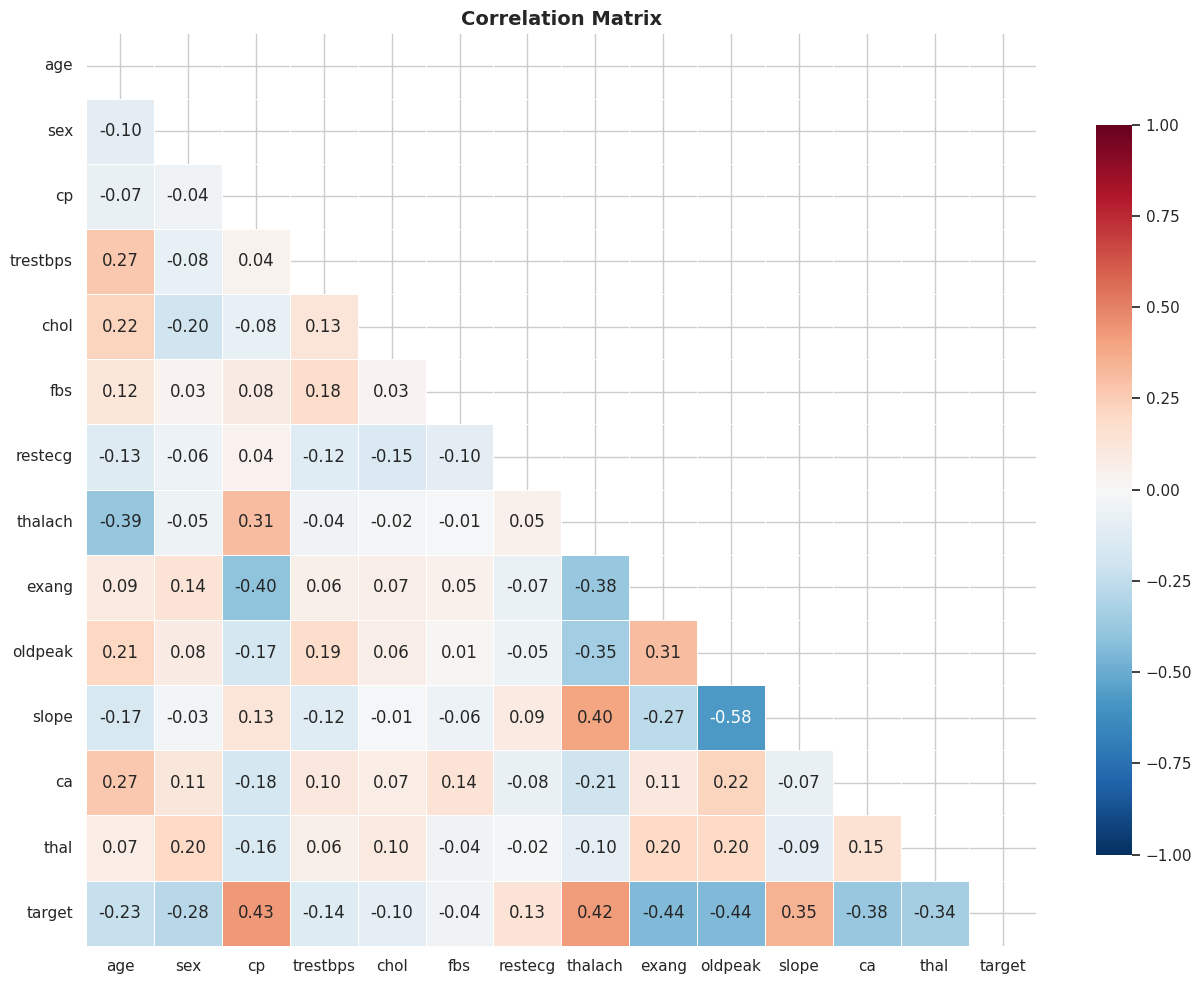

In [29]:
fig, ax = plt.subplots(figsize=(13, 10))

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

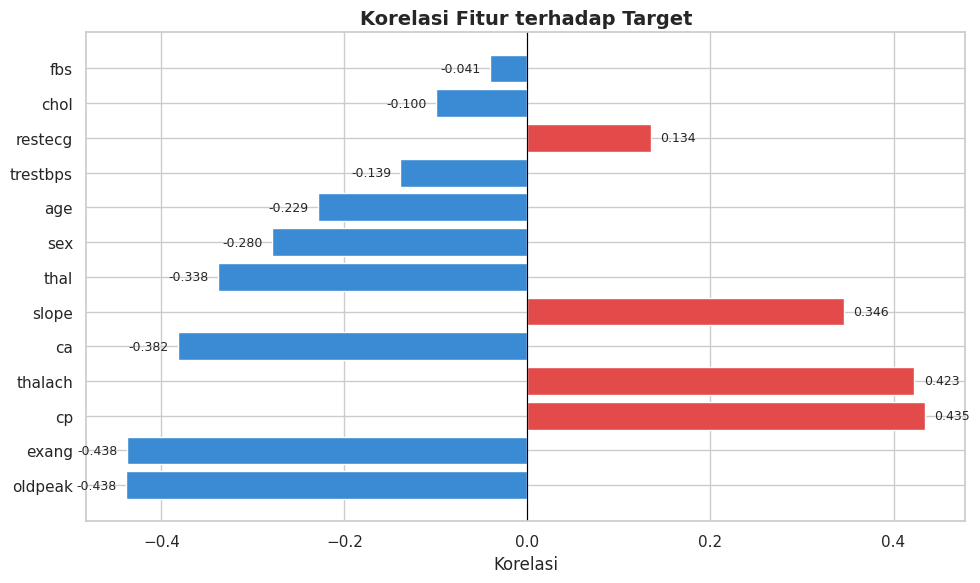


Fitur dengan korelasi tertinggi terhadap target:
oldpeak   -0.438
exang     -0.438
cp         0.435
thalach    0.423
ca        -0.382
Name: target, dtype: float64


In [30]:
target_corr = df.corr(numeric_only=True)['target'].drop('target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E24B4A' if v > 0 else '#3B8BD4' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap Target', fontsize=14, fontweight='bold')
ax.set_xlabel('Korelasi')

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nFitur dengan korelasi tertinggi terhadap target:')
print(target_corr.head(5))

In [31]:
print('='*55)
print('         RINGKASAN EDA - HEART DISEASE DATASET')
print('='*55)
print(f'Jumlah sampel          : {df.shape[0]}')
print(f'Jumlah fitur           : {df.shape[1] - 1}')
print(f'Missing values         : {df.isnull().sum().sum()}')
print(f'Duplikat               : {df.duplicated().sum()}')
print(f'Target distribution    : {dict(df["target"].value_counts())}')
print()
print('Outlier per kolom numerik (IQR method):')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:<12}: {n_out} outlier')
print('='*55)

         RINGKASAN EDA - HEART DISEASE DATASET
Jumlah sampel          : 1025
Jumlah fitur           : 13
Missing values         : 0
Duplikat               : 723
Target distribution    : {1: np.int64(526), 0: np.int64(499)}

Outlier per kolom numerik (IQR method):
  age         : 0 outlier
  trestbps    : 30 outlier
  chol        : 16 outlier
  thalach     : 4 outlier
  oldpeak     : 7 outlier


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [32]:
df_clean = df.copy()
print(f'Salinan dataset dibuat. Shape: {df_clean.shape}')

Salinan dataset dibuat. Shape: (1025, 14)


In [33]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'Sebelum  : {before} baris')
print(f'Sesudah  : {after} baris')
print(f'Dihapus  : {before - after} duplikat')

Sebelum  : 1025 baris
Sesudah  : 302 baris
Dihapus  : 723 duplikat


In [34]:
print('Missing values sebelum handling:')
print(df_clean.isnull().sum())

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  Kolom "{col}" diisi median: {median_val:.2f}')

print(f'\nTotal missing values sesudah: {df_clean.isnull().sum().sum()}')

Missing values sebelum handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values sesudah: 0


In [35]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print('Penanganan outlier dengan IQR Capping:')
print('-' * 50)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'{col:<12}: {n_outlier} outlier → di-cap ke [{lower:.2f}, {upper:.2f}]')

print('-' * 50)
print(f'Shape setelah outlier handling: {df_clean.shape}')

Penanganan outlier dengan IQR Capping:
--------------------------------------------------
age         : 0 outlier → di-cap ke [28.50, 80.50]
trestbps    : 9 outlier → di-cap ke [90.00, 170.00]
chol        : 5 outlier → di-cap ke [115.38, 370.38]
thalach     : 1 outlier → di-cap ke [84.12, 215.12]
oldpeak     : 5 outlier → di-cap ke [-2.40, 4.00]
--------------------------------------------------
Shape setelah outlier handling: (302, 14)


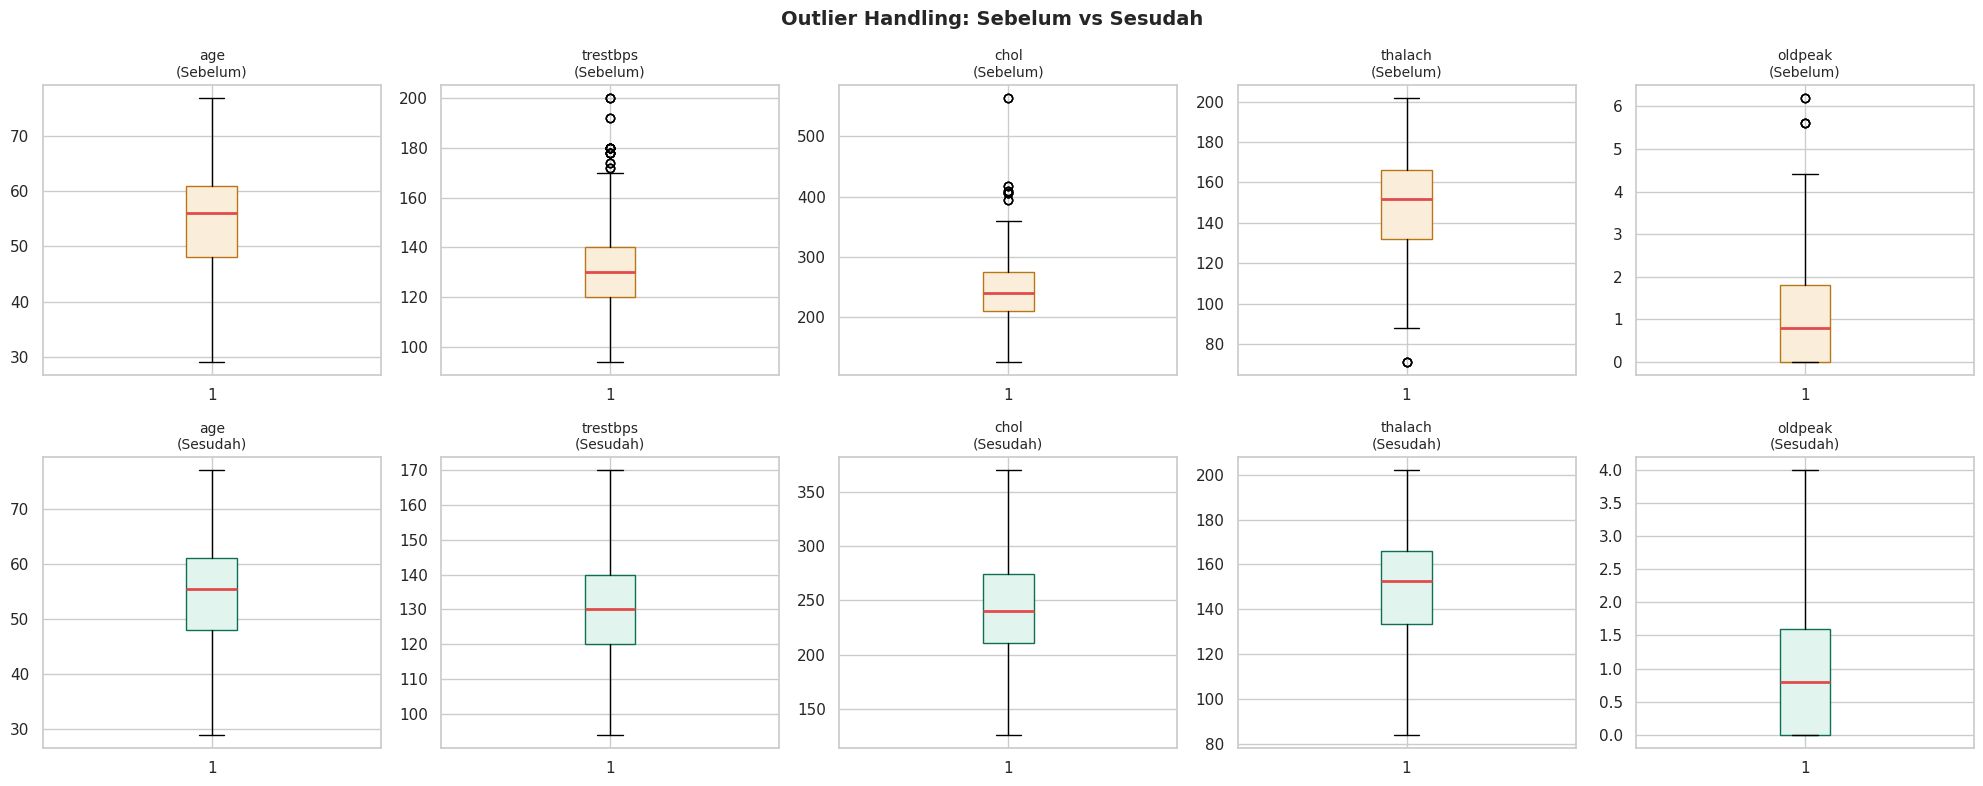

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(numeric_cols):
    axes[0, i].boxplot(df[col], patch_artist=True,
                        boxprops=dict(facecolor='#FAEEDA', color='#BA7517'),
                        medianprops=dict(color='#E24B4A', linewidth=2))
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontsize=10)

    axes[1, i].boxplot(df_clean[col], patch_artist=True,
                        boxprops=dict(facecolor='#E1F5EE', color='#0F6E56'),
                        medianprops=dict(color='#E24B4A', linewidth=2))
    axes[1, i].set_title(f'{col}\n(Sesudah)', fontsize=10)

plt.suptitle('Outlier Handling: Sebelum vs Sesudah', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 55, 70, 100],
    labels=[0, 1, 2, 3]
).astype(int)

df_clean['chol_age_ratio'] = df_clean['chol'] / (df_clean['age'] + 1)

print('Fitur baru berhasil ditambahkan:')
print(f'  age_group     : {df_clean["age_group"].value_counts().to_dict()}')
print(f'  chol_age_ratio: min={df_clean["chol_age_ratio"].min():.2f}, max={df_clean["chol_age_ratio"].max():.2f}, mean={df_clean["chol_age_ratio"].mean():.2f}')
print(f'\nShape setelah feature engineering: {df_clean.shape}')
df_clean.head(3)

Fitur baru berhasil ditambahkan:
  age_group     : {2: 145, 1: 133, 0: 18, 3: 6}
  chol_age_ratio: min=2.07, max=8.03, mean=4.52

Shape setelah feature engineering: (302, 16)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_age_ratio
0,52,1,0,125,212.000,0,1,168.000,0,1.000,2,2,3,0,1,4.000
1,53,1,0,140,203.000,1,0,155.000,1,3.100,0,0,3,0,1,3.759
2,70,1,0,145,174.000,0,1,125.000,1,2.600,0,0,3,0,2,2.451


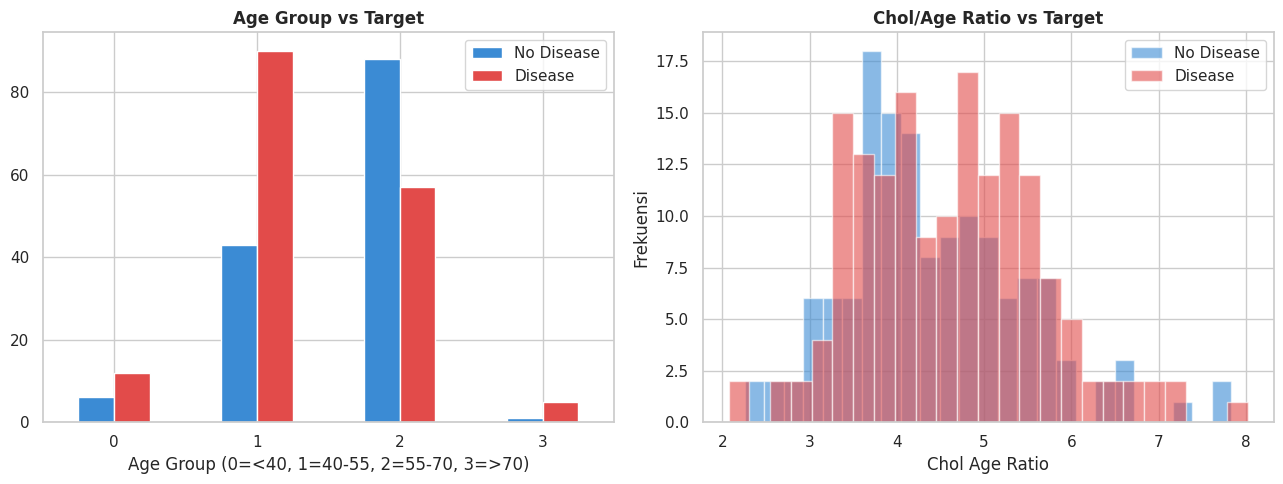

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ct_age = pd.crosstab(df_clean['age_group'], df_clean['target'])
ct_age.plot(kind='bar', ax=axes[0], color=['#3B8BD4', '#E24B4A'],
             edgecolor='white', rot=0)
axes[0].set_title('Age Group vs Target', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group (0=<40, 1=40-55, 2=55-70, 3=>70)')
axes[0].legend(['No Disease', 'Disease'])

for target_val, color, label in zip([0, 1], ['#3B8BD4', '#E24B4A'], ['No Disease', 'Disease']):
    data = df_clean[df_clean['target'] == target_val]['chol_age_ratio']
    axes[1].hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Chol/Age Ratio vs Target', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Chol Age Ratio')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'chol_age_ratio']

print('Statistik sebelum scaling:')
print(df_clean[scale_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3))

scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print('\nStatistik sesudah scaling:')
print(df_clean[scale_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3))

print(f'\nShape setelah scaling: {df_clean.shape}')

Statistik sebelum scaling:
        age  trestbps    chol  thalach  oldpeak  chol_age_ratio
mean 54.421   131.258 245.377  149.613    1.028           4.525
std   9.048    16.605  47.487   22.766    1.110           1.043
min  29.000    94.000 126.000   84.125    0.000           2.069
max  77.000   170.000 370.375  202.000    4.000           8.025

Statistik sesudah scaling:
        age  trestbps   chol  thalach  oldpeak  chol_age_ratio
mean -0.000     0.000 -0.000   -0.000    0.000           0.000
std   1.002     1.002  1.002    1.002    1.002           1.002
min  -2.814    -2.247 -2.518   -2.881   -0.927          -2.358
max   2.500     2.337  2.637    2.305    2.681           3.362

Shape setelah scaling: (302, 16)


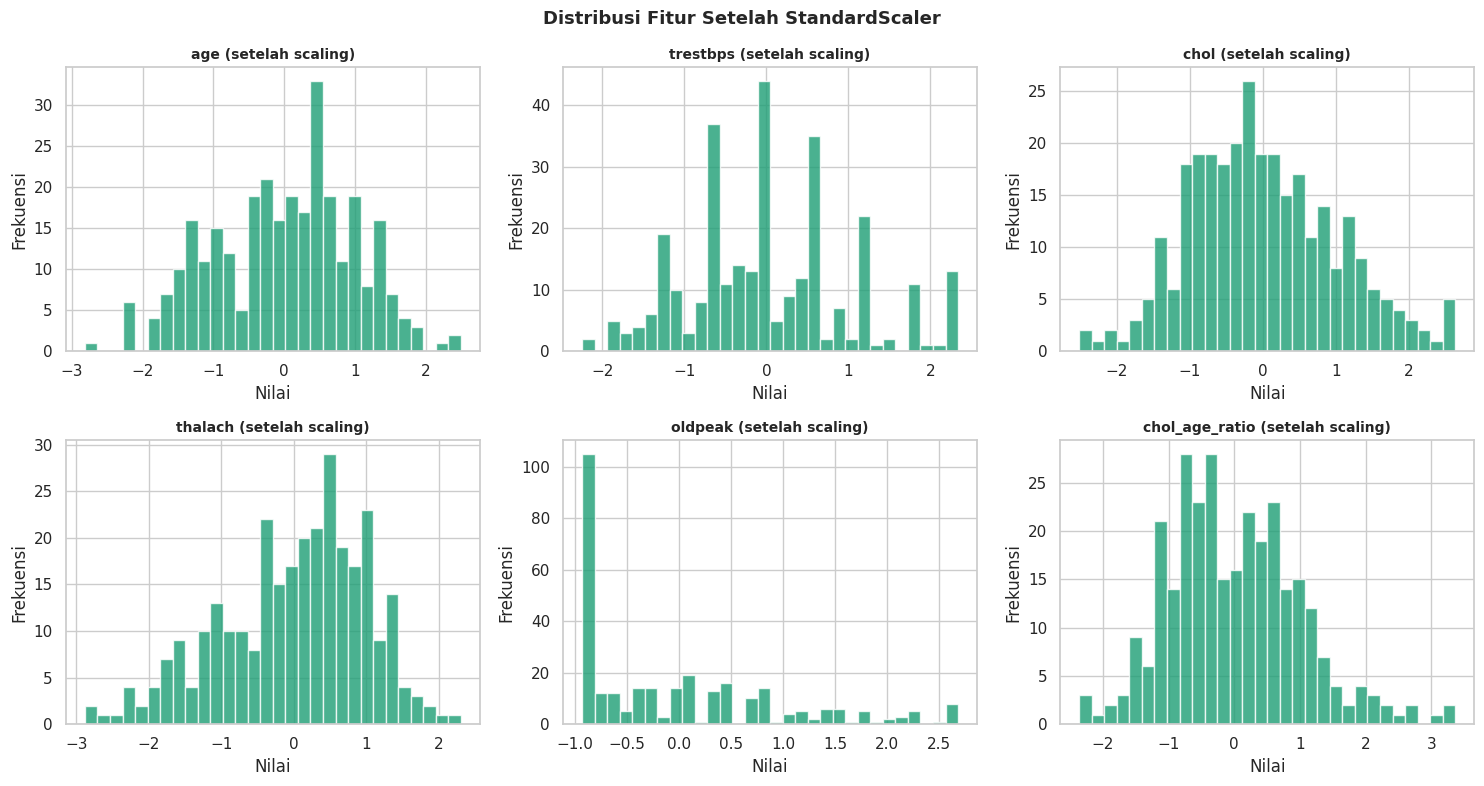

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(scale_cols):
    axes[i].hist(df_clean[col], bins=30, color='#1D9E75', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} (setelah scaling)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Fitur Setelah StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
TARGET_COL = 'target'

X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split Selesai:')
print(f'  Total sampel  : {len(df_clean)}')
print(f'  X_train shape : {X_train.shape}')
print(f'  X_test shape  : {X_test.shape}')
print(f'  y_train dist  : {dict(y_train.value_counts())}')
print(f'  y_test dist   : {dict(y_test.value_counts())}')

Train-Test Split Selesai:
  Total sampel  : 302
  X_train shape : (241, 15)
  X_test shape  : (61, 15)
  y_train dist  : {1: np.int64(131), 0: np.int64(110)}
  y_test dist   : {1: np.int64(33), 0: np.int64(28)}


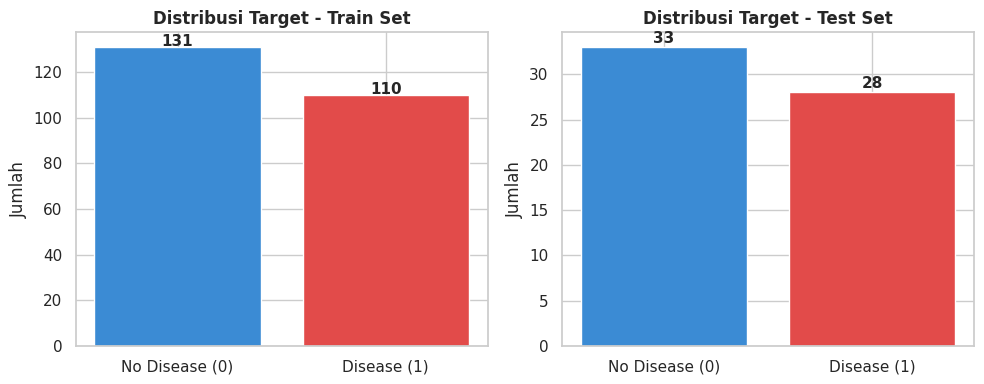

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_data, title in zip(axes, [y_train, y_test], ['Train Set', 'Test Set']):
    counts = y_data.value_counts()
    ax.bar(['No Disease (0)', 'Disease (1)'], counts.values,
           color=['#3B8BD4', '#E24B4A'], edgecolor='white')
    ax.set_title(f'Distribusi Target - {title}', fontweight='bold')
    ax.set_ylabel('Jumlah')
    for j, v in enumerate(counts.values):
        ax.text(j, v + 0.5, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [43]:
OUTPUT_DIR = 'heart_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_clean.to_csv(f'{OUTPUT_DIR}/heart_preprocessing.csv', index=False)

train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)

train_df.to_csv(f'{OUTPUT_DIR}/heart_train.csv', index=False)
test_df.to_csv(f'{OUTPUT_DIR}/heart_test.csv',   index=False)

print('Dataset berhasil disimpan!')
print(f'  heart_preprocessing.csv : {df_clean.shape}')
print(f'  heart_train.csv         : {train_df.shape}')
print(f'  heart_test.csv          : {test_df.shape}')
print(f'\nSemua file ada di folder: {OUTPUT_DIR}/')

for f in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(path)
    print(f'  {f} ({size:,} bytes)')

Dataset berhasil disimpan!
  heart_preprocessing.csv : (302, 16)
  heart_train.csv         : (241, 16)
  heart_test.csv          : (61, 16)

Semua file ada di folder: heart_preprocessing/
  heart_train.csv (33,346 bytes)
  heart_preprocessing.csv (41,758 bytes)
  heart_test.csv (8,517 bytes)


In [44]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print('='*50)
print('   SANITY CHECK - Model Baseline')
print('='*50)
print(f'Algoritma      : Random Forest')
print(f'Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

   SANITY CHECK - Model Baseline
Algoritma      : Random Forest
Test Accuracy  : 0.8033 (80.33%)

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.79      0.79        28
     Disease       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



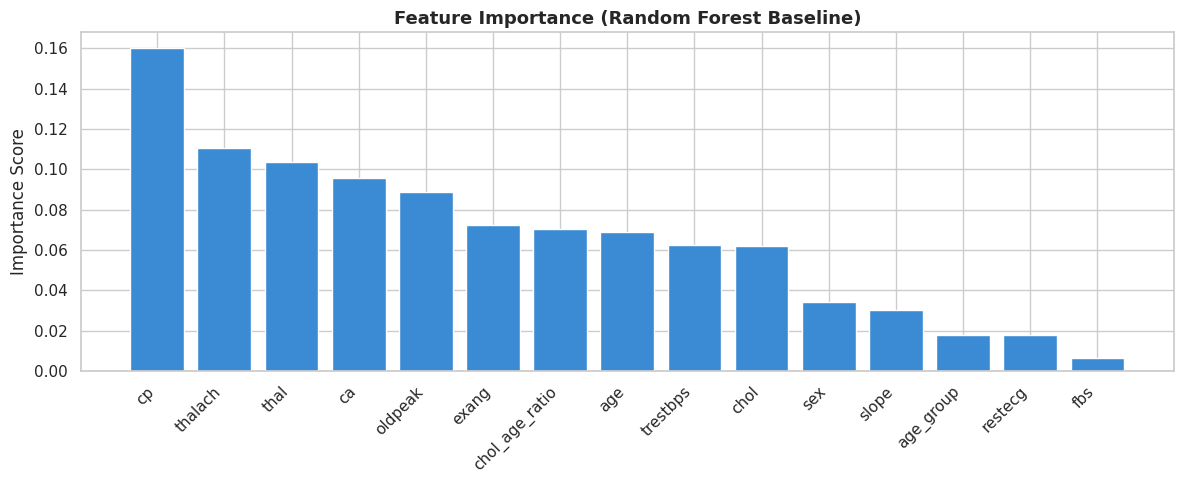


Top 5 fitur terpenting:
  cp                : 0.1599
  thalach           : 0.1103
  thal              : 0.1037
  ca                : 0.0955
  oldpeak           : 0.0889


In [45]:
importances = model.feature_importances_
feat_names = X_train.columns.tolist()
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(importances)), importances[sorted_idx],
               color='#3B8BD4', edgecolor='white')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title('Feature Importance (Random Forest Baseline)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')

plt.tight_layout()
plt.show()

print('\nTop 5 fitur terpenting:')
for i in sorted_idx[:5]:
    print(f'  {feat_names[i]:<18}: {importances[i]:.4f}')